<a href="https://colab.research.google.com/github/akshadjaiswal005/Machine-Learning-TAE1-Group8/blob/main/Tisha_Models/Tisha_SVM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS23059 Tisha Mondal (SUPPORT VECTOR MACHINE MODEL)

# Support Vector Machine (SVM) Model - Heart Disease Prediction

This notebook implements the Support Vector Machine (SVM) algorithm on the UCI Heart Disease dataset.  
It includes data preprocessing, feature engineering, model training, kernel comparison, and performance evaluation  
using metrics such as accuracy, confusion matrix, and classification report.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Model
from sklearn.svm import SVC

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
url = "https://raw.githubusercontent.com/akshadjaiswal005/Machine-Learning-TAE1-Group8/refs/heads/main/heart_disease_uci.csv"
df = pd.read_csv(url)

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
# Data Understanding
print("Dataset Shape:", df.shape)

print("\nColumns:\n", df.columns)

print("\nInfo:")
df.info()

print("\nSummary:")
print(df.describe())

Dataset Shape: (920, 16)

Columns:
 Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       92

In [5]:
# Handle Missing Values
print("\nNull Values:\n", df.isnull().sum())

before_rows = df.shape[0]
df = df.dropna()
after_rows = df.shape[0]

print("Before rows:", before_rows)
print("After rows:", after_rows)
print("Dropped rows:", before_rows - after_rows)


Null Values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
Before rows: 920
After rows: 299
Dropped rows: 621


In [6]:
# Convert Target
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

num
0    160
1    139
Name: count, dtype: int64


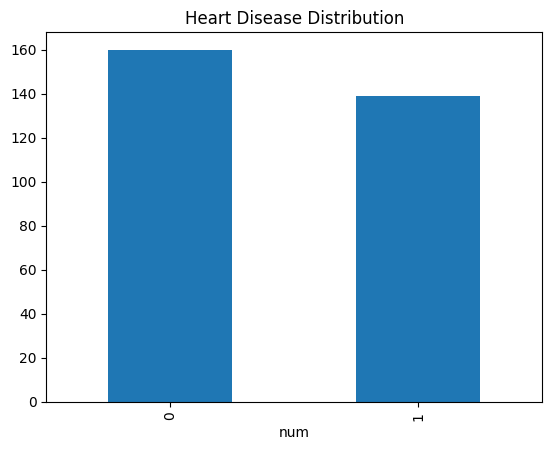

In [7]:
# Class Distribution
import matplotlib.pyplot as plt

print(df['num'].value_counts())

df['num'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.show()

In [8]:
# Drop Unnecessary Column
df = df.drop("id", axis=1)

In [9]:
# Encode Categorical Data
df = pd.get_dummies(df, drop_first=True)

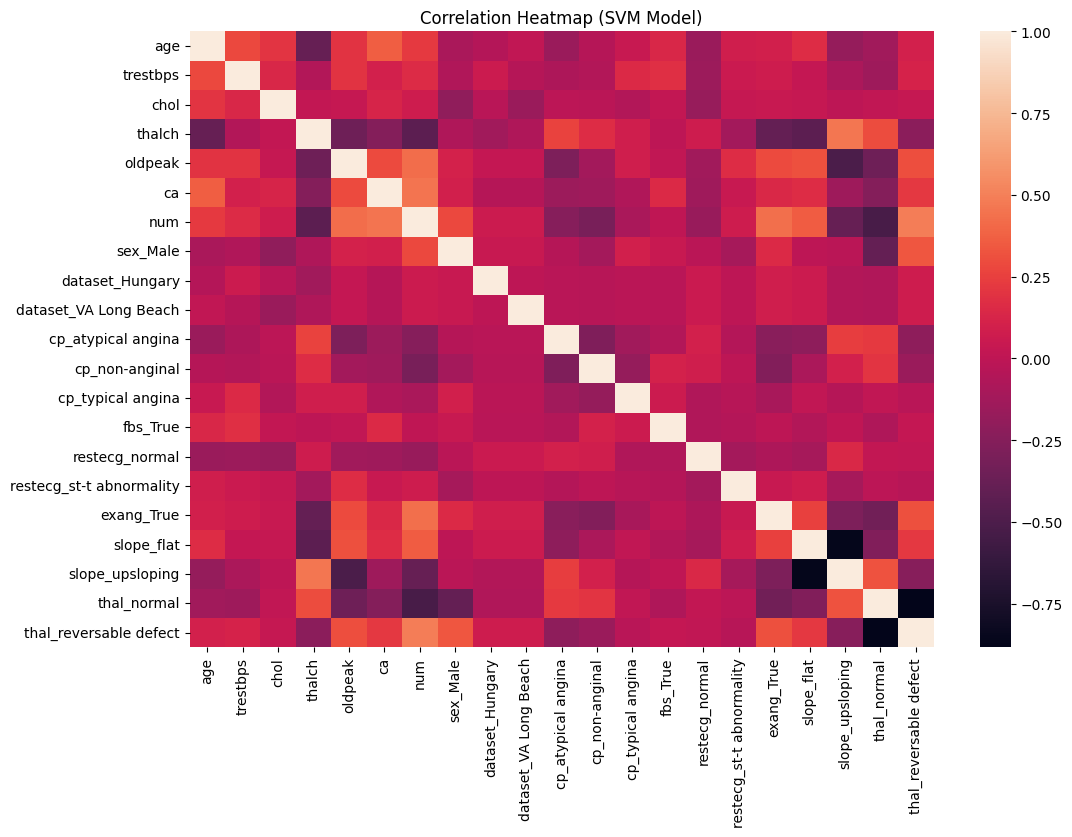

In [10]:
# Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap (SVM Model)")
plt.show()

In [11]:
# Define Features & Target
X = df.drop("num", axis=1)
y = df["num"]

In [12]:
# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [13]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

PART A: SVM CLASSIFICATION

In [14]:
# Train Model
svm_model = SVC(kernel='rbf', C=1.0)
svm_model.fit(X_train, y_train)

SVC()

In [15]:
# Different SVM Kernels Comparison

# Linear Kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))


# Polynomial Kernel
svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

print("Polynomial Kernel Accuracy:", accuracy_score(y_test, y_pred_poly))


# Sigmoid Kernel
svm_sigmoid = SVC(kernel='sigmoid')
svm_sigmoid.fit(X_train, y_train)
y_pred_sigmoid = svm_sigmoid.predict(X_test)

print("Sigmoid Kernel Accuracy:", accuracy_score(y_test, y_pred_sigmoid))

Linear Kernel Accuracy: 0.9166666666666666
Polynomial Kernel Accuracy: 0.8833333333333333
Sigmoid Kernel Accuracy: 0.9


In [16]:
# Testing different C values

for c_val in [0.1, 1, 100]:
    model = SVC(C=c_val)
    model.fit(X_train, y_train)
    y_pred_c = model.predict(X_test)

    print(f"C={c_val} Accuracy:", accuracy_score(y_test, y_pred_c))

C=0.1 Accuracy: 0.8333333333333334
C=1 Accuracy: 0.85
C=100 Accuracy: 0.8


In [17]:
# Prediction
y_pred = svm_model.predict(X_test)

PART B: PERFORMANCE EVALUATION

In [18]:
print("\nFinal Model Evaluation:")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Final Model Evaluation:
Confusion Matrix:
 [[31  4]
 [ 5 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87        35
           1       0.83      0.80      0.82        25

    accuracy                           0.85        60
   macro avg       0.85      0.84      0.84        60
weighted avg       0.85      0.85      0.85        60



In [19]:
# Performance Metrics
print("=== SVM Classification Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== SVM Classification Results ===
Accuracy: 0.85

Confusion Matrix:
 [[31  4]
 [ 5 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87        35
           1       0.83      0.80      0.82        25

    accuracy                           0.85        60
   macro avg       0.85      0.84      0.84        60
weighted avg       0.85      0.85      0.85        60



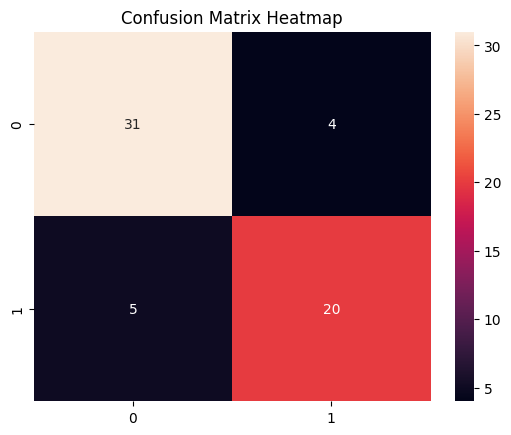

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix Heatmap")
plt.show()

In [21]:
# Train vs Test Accuracy
print("\nTraining Accuracy:", svm_model.score(X_train, y_train))
print("Testing Accuracy:", svm_model.score(X_test, y_test))


Training Accuracy: 0.899581589958159
Testing Accuracy: 0.85


In [22]:
# Try Different Kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

print("\nLinear Kernel Accuracy:", svm_linear.score(X_test, y_test))


Linear Kernel Accuracy: 0.9166666666666666


Conclusion:
The Support Vector Machine (SVM) model was successfully implemented on the Heart Disease dataset.
Different kernels such as linear, polynomial, and sigmoid were evaluated to compare performance.
The model achieved good classification accuracy, and performance was analyzed using confusion matrix and classification report.
Hyperparameter tuning using different C values helped in improving model performance.
Overall, SVM proved to be an effective model for heart disease prediction.